# Model Analysis — Logistic Regression

This notebook develops and compares logistic regression models to predict customer response to a monthly food basket subscription campaign for a retail food company. Building on the EDA, which identified behavioural variables, particularly past campaign acceptance and recency, as the strongest predictors of response, the modelling strategy follows a structured diagnostic logic:

1. A **Full Model** trained on all engineered features to identify which predictors survive penalisation.
2. A **Behavioural Model** focusing on engagement and purchase history.
3. A **Demographic Model** focusing on customer profile and household composition.

Comparing these three models allows us to assess whether campaign response is better explained by *who the customer is* or *how the customer behaves*, and to select the most actionable model for deployment.

## 0. Setup & Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict,
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from scipy.stats import loguniform

import warnings
warnings.filterwarnings('ignore')

# Cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# OOF threshold tuning helper
def find_best_threshold_oof(pipeline, X_train, y_train, cv=5):
    oof_probs = cross_val_predict(
        pipeline, X_train, y_train, cv=cv, method="predict_proba"
    )[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"Optimal threshold (F1): {best_threshold:.4f}")
    print(f"Best OOF F1:            {best_f1:.4f}")

    return best_threshold

#Standardised evaluation helper
def evaluate_model(model, X_te, y_te, model_name, threshold=0.5):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model':     model_name,
        'Threshold': round(threshold, 4),
        'ROC-AUC':   round(roc_auc_score(y_te, y_prob), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1':        round(f1_score(y_te, y_pred, zero_division=0), 4),
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
    }

In [6]:
# Data loading
df = pd.read_csv('../data/marketing_campaign_clean.csv')

# Data overview
print(f"Dataset shape: {df.shape}")
print(f"\nClass balance:")
print(df['Response'].value_counts(normalize=True).round(3))
df.columns

Dataset shape: (2236, 30)

Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Income_missing', 'Customer_Tenure', 'Age',
       'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
       'Response'],
      dtype='object')

## 1. Feature Selection

The clean dataset already includes the engineered features from the EDA notebook
(`Total_Spending`, `Total_Purchases`, `Total_Accepted_Campaigns`, `Customer_Tenure`, `Age`).

The original columns (individual spend categories and individual campaign dummies) are
dropped here, as they have been combined into the aggregated features. `Income_missing` and
`Complain` are also dropped.

To enable clean model comparisons, three non-overlapping feature sets are constructed upfront and in the following section.

In [7]:
# Create copy of the dataframe for modeling
df_model = df.copy()

# Drop columns that won't be used in the model
cols_to_drop = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Income_missing', 'Complain'
]

df_model = df_model.drop(columns=cols_to_drop)


# Define features and target
target = 'Response'

## Full Model
numerical_features_full = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]
categorical_features_full = ['Education', 'Marital_Status']

## Behavioural Model
numerical_features_behav = [
    'Recency', 'Total_Spending', 'Total_Purchases',
    'Total_Accepted_Campaigns', 'NumDealsPurchases', 'NumWebVisitsMonth'
]
categorical_features_behav = [] 

# Demographic Model
numerical_features_demo = [
    'Age', 'Income', 'Customer_Tenure',
    'Kidhome', 'Teenhome'
]
categorical_features_demo = ['Education', 'Marital_Status']


print(f"Full model: {len(numerical_features_full)} numerical + {len(categorical_features_full)} categorical")
print(f"Behavioural: {len(numerical_features_behav)} numerical + {len(categorical_features_behav)} categorical")
print(f"Demographic: {len(numerical_features_demo)} numerical + {len(categorical_features_demo)} categorical")

Full model: 11 numerical + 2 categorical
Behavioural: 6 numerical + 0 categorical
Demographic: 5 numerical + 2 categorical


## 2. Train/Test Split

The train and test indices were created once in the EDA notebook (Section 9) using a stratified 80/20 split with `random_state=42`, and saved to disk as `.npy` files.

Loading them here, rather than calling `train_test_split` again, guarantees that this notebook uses exactly the same observations as the advanced models developed in this project, making cross-model comparisons statistically valid.

In [8]:
X_all = df_model[numerical_features_full + categorical_features_full]
y = df_model[target]

# Load the shared split indices produced in EDA.ipynb (Section 9)
idx_train = np.load('../data/idx_train.npy')
idx_test  = np.load('../data/idx_test.npy')

# Slice each feature matrix and the target using the shared indices
X_train_all = X_all.iloc[idx_train]
X_test_all  = X_all.iloc[idx_test]
y_train     = y.iloc[idx_train]
y_test      = y.iloc[idx_test]

X_train_full  = X_train_all[numerical_features_full + categorical_features_full]
X_test_full   = X_test_all[numerical_features_full + categorical_features_full]

X_train_behav = X_train_all[numerical_features_behav]
X_test_behav  = X_test_all[numerical_features_behav]

X_train_demo = X_train_all[numerical_features_demo + categorical_features_demo]
X_test_demo  = X_test_all[numerical_features_demo + categorical_features_demo]

print(f'Train size: {len(y_train):,}  (positives: {y_train.sum()})')
print(f'Test size:  {len(y_test):,}   (positives: {y_test.sum()})')
print(f'Train positive rate: {y_train.mean():.1%}')
print(f'Test  positive rate: {y_test.mean():.1%}')


Train size: 1,788  (positives: 267)
Test size:  448   (positives: 67)
Train positive rate: 14.9%
Test  positive rate: 15.0%


**Class Imbalance and Evaluation Strategy**
The target variable is imbalanced, with only a relatively small share of customers responding positively to the campaign. 

For this project, identifying actual responders is the key business objective, so Precision, Recall, F1, Precision-Recall curves, and threshold selection (in addition to ROC-AUC) are also required to evaluate whether the model is operationally useful.

In [9]:
positive_rate = df['Response'].mean()
negative_rate = 1 - positive_rate

print(f"Positive class rate: {positive_rate:.2%}")
print(f"Negative class rate: {negative_rate:.2%}")
print(f"Class ratio (No Response : Response) = {negative_rate/positive_rate:.2f} : 1")


Positive class rate: 14.94%
Negative class rate: 85.06%
Class ratio (No Response : Response) = 5.69 : 1


## 3. Full Model - Elastic Net Regularization

The full model employs **Elastic Net** regularisation, which combines L1  and L2 penalties in a weighted sum governed by `l1_ratio`. The choice of  Elastic Net over pure L1 or L2 is validated empirically in Section 3.2 through a cross-validated comparison of all regularisation strategies at a fixed `C=1.0`.

### 3.1. Baseline Model (No Tuning)

Before making any modelling decisions, a baseline Logistic Regression model is trained using scikit-learn’s default configuration (C=1.0, lbfgs solver). Under this setup, L2 regularization is applied by default, but no explicit tuning of the regularization type, strength, or class imbalance handling is performed. 

This model serves as a reference point against which subsequent improvements (such as the introduction of Elastic Net regularization and hyperparameter optimization) are evaluated in terms of ROC-AUC.

In [10]:
# Helper to create a fresh preprocessor for each model (to avoid data leakage from fitting on the full training set)
def make_preprocessor_full():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_full),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features_full)
    ])

# Baseline with sklearn defaults (L2, C=1.0, lbfgs)
full_model_base = Pipeline(steps=[
    ('preprocessor', make_preprocessor_full()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])
baseline_auc_full = cross_val_score(
    full_model_base,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

baseline_f1_full = cross_val_score(
    full_model_base,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='f1'
)

baseline_recall_full = cross_val_score(
    full_model_base,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='recall'
)

print("Baseline Logistic Regression — Full Model (training CV only)")
print(f"ROC-AUC : {baseline_auc_full.mean():.4f} ± {baseline_auc_full.std():.4f}")
print(f"Recall  : {baseline_recall_full.mean():.4f} ± {baseline_recall_full.std():.4f}")
print(f"F1      : {baseline_f1_full.mean():.4f} ± {baseline_f1_full.std():.4f}")

Baseline Logistic Regression — Full Model (training CV only)
ROC-AUC : 0.8881 ± 0.0207
Recall  : 0.8089 ± 0.0386
F1      : 0.5602 ± 0.0362


### 3.2. Regularization Strategy Selection

To determine the appropriate level of model complexity, four logistic regression specifications were compared on the training set using 5-fold stratified cross-validation: no regularization, L2, L1, and Elastic Net. 

The comparison was based on ROC-AUC, since the objective at this stage was to assess each model’s ability to discriminate between responders and non-responders independently of any classification threshold.

In [11]:
# Compare regularisation strategies
from sklearn.model_selection import cross_val_score

reg_configs = [
    {
        'name':    'No Regularisation',
        'penalty': None,
        'solver':  'lbfgs',
        'C':       1.0,      
        'l1_ratio': None,
    },
    {
        'name':    'L2 (Ridge)',
        'penalty': 'l2',
        'solver':  'lbfgs',
        'C':       1.0,
        'l1_ratio': None,
    },
    {
        'name':    'L1 (Lasso)',
        'penalty': 'l1',
        'solver':  'saga',
        'C':       1.0,
        'l1_ratio': None,
    },
    {
        'name':    'Elastic Net',
        'penalty': 'elasticnet',
        'solver':  'saga',
        'C':       1.0,
        'l1_ratio': 0.5,
    },
]

reg_results = []
for cfg in reg_configs:
    lr_kwargs = dict(
        penalty=cfg['penalty'],
        solver=cfg['solver'],
        C=cfg['C'],
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    if cfg['l1_ratio'] is not None:
        lr_kwargs['l1_ratio'] = cfg['l1_ratio']

    pipe = Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier',   LogisticRegression(**lr_kwargs))
    ])

    scores = cross_val_score(
        pipe, X_train_full, y_train,
        cv=cv_strategy, scoring='roc_auc'
    )
    reg_results.append({
        'Regularisation': cfg['name'],
        'CV AUC Mean':    round(scores.mean(), 4),
        'CV AUC Std':     round(scores.std(), 4),
    })

reg_df = pd.DataFrame(reg_results).set_index('Regularisation')
print("Regularisation Strategy Comparison (C=1.0, untuned)\n")
print(reg_df.to_string())

Regularisation Strategy Comparison (C=1.0, untuned)

                   CV AUC Mean  CV AUC Std
Regularisation                            
No Regularisation       0.8816      0.0150
L2 (Ridge)              0.8881      0.0207
L1 (Lasso)              0.8880      0.0209
Elastic Net             0.8882      0.0207


The results show that all three regularized models perform very similarly, with cross-validated ROC-AUC values close to 0.888, while the unregularized specification performs slightly worse. Among the regularized alternatives, **Elastic Net** achieved the highest average ROC-AUC, although the difference relative to L1 and L2 is small.

Because Elastic Net delivered the strongest validation performance, it was retained as the preferred regularization strategy for the full model. In addition, it offers a useful compromise between L1 and L2 penalties by combining coefficient shrinkage with sparse feature selection.

### 3.3 Hyperparameter Tuning (RandomizedSearchCV + GridSearchCV)


After selecting **Elastic Net** as the preferred regularization strategy, its two main hyperparameters, `C` and `l1_ratio`, were tuned using cross-validation on the training set only. To balance efficiency and precision, tuning was carried out in two stages.

First, a RandomizedSearchCV explored a broad range of values for C and several candidate values for l1_ratio, identifying the most promising region of the parameter space. Next, a narrower GridSearchCV was performed around the best C value from the randomized search while keeping the best l1_ratio fixed.





In [12]:
# Broad randomized search
param_dist = {
    'classifier__C': loguniform(1e-3, 10),
    'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

rand_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier', LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_distributions=param_dist,
    n_iter=30,
    cv=cv_strategy,
    scoring='roc_auc',
    random_state=42,
    n_jobs=1,
    verbose=1
)

rand_search.fit(X_train_full, y_train)

best_C_rand = rand_search.best_params_['classifier__C']
best_l1_rand = rand_search.best_params_['classifier__l1_ratio']

print("Stage 1 — RandomizedSearchCV")
print(f"Best parameters: {rand_search.best_params_}")
print(f"Best CV AUC:    {rand_search.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Stage 1 — RandomizedSearchCV
Best parameters: {'classifier__C': np.float64(0.7726718477963437), 'classifier__l1_ratio': 0.3}
Best CV AUC:    0.8881


In [13]:
# narrower grid search around the best C from Stage 1
param_grid = {
    'classifier__C': [
        best_C_rand * 0.5,
        best_C_rand,
        best_C_rand * 1.5,
        best_C_rand * 2
    ],
    'classifier__l1_ratio': [best_l1_rand]
}

grid_search = GridSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', make_preprocessor_full()),
        ('classifier', LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=1,
    verbose=1
)

grid_search.fit(X_train_full, y_train)

best_C_final = grid_search.best_params_['classifier__C']
best_l1_final = grid_search.best_params_['classifier__l1_ratio']

print("\nStage 2 — GridSearchCV")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC:    {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 4 candidates, totalling 20 fits

Stage 2 — GridSearchCV
Best parameters: {'classifier__C': np.float64(0.38633592389817184), 'classifier__l1_ratio': 0.3}
Best CV AUC:    0.8881


### 3.4 Tuning Progression & Best Parameter Selection

Hyperparameter Tuning Progression — Full Logistic Regression
                                  C  l1_ratio  CV AUC
Stage                                                
Stage 1\nRandomizedSearchCV  0.7727       0.3  0.8881
Stage 2\nGridSearchCV        0.3863       0.3  0.8881


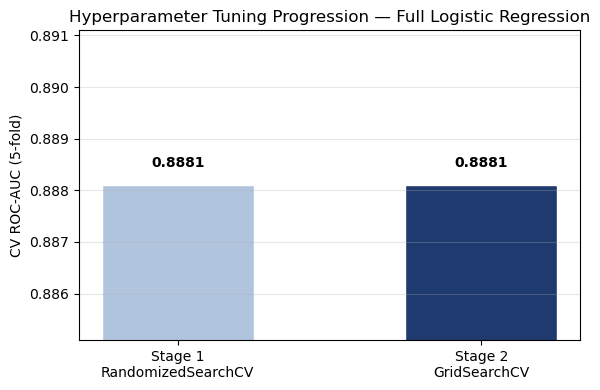

In [14]:
tuning_summary = [
    {
        'Stage':    'Stage 1\nRandomizedSearchCV',
        'C':        round(rand_search.best_params_['classifier__C'], 4),
        'l1_ratio': rand_search.best_params_['classifier__l1_ratio'],
        'CV AUC':   round(rand_search.best_score_, 4),
    },
    {
        'Stage':    'Stage 2\nGridSearchCV',
        'C':        round(grid_search.best_params_['classifier__C'], 4),
        'l1_ratio': grid_search.best_params_['classifier__l1_ratio'],
        'CV AUC':   round(grid_search.best_score_, 4),
    },
]

tuning_df = pd.DataFrame(tuning_summary).set_index('Stage')
print("Hyperparameter Tuning Progression — Full Logistic Regression")
print(tuning_df.to_string())

# Bar chart: CV AUC progression
aucs = [r['CV AUC'] for r in tuning_summary]
labels = [r['Stage'] for r in tuning_summary]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    labels,
    aucs,
    color=['#b0c4de', '#1e3a6e'],
    edgecolor='white',
    width=0.5
)

ax.set_ylim(min(aucs) - 0.003, max(aucs) + 0.003)
ax.set_ylabel("CV ROC-AUC (5-fold)")
ax.set_title("Hyperparameter Tuning Progression — Full Logistic Regression")

for bar, auc in zip(bars, aucs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        f"{auc:.4f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


The randomized and grid search stages both achieved the same cross-validated **ROC-AUC of 0.8881**, indicating that the Elastic Net model performs stably across nearby hyperparameter values. The grid search refined the regularization strength from **C = 0.7727 to C = 0.3863** while retaining **l1_ratio = 0.3**, but this adjustment did not improve predictive performance.

The final full model therefore uses the grid-search parameters, although the results show that the model is not highly sensitive to small changes in the Elastic Net configuration.





In [15]:
# Rebuild full model with final grid-search parameters
best_C_final = grid_search.best_params_['classifier__C']
best_l1_final = grid_search.best_params_['classifier__l1_ratio']

full_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_full()),
    ('classifier', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=best_C_final,
        l1_ratio=best_l1_final,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

full_model.fit(X_train_full, y_train)

cv_scores_full = cross_val_score(
    full_model,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

baseline_cv_full = cross_val_score(
    full_model_base,
    X_train_full,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

print("Final Elastic Net Model — Full Feature Set")
print(f"C = {best_C_final:.4f}")
print(f"l1_ratio = {best_l1_final}")
print(f"CV ROC-AUC      : {cv_scores_full.mean():.4f} ± {cv_scores_full.std():.4f}")
print(f"Baseline CV AUC : {baseline_cv_full.mean():.4f}")
print(f"Delta vs baseline: {cv_scores_full.mean() - baseline_cv_full.mean():+.4f}")


Final Elastic Net Model — Full Feature Set
C = 0.3863
l1_ratio = 0.3
CV ROC-AUC      : 0.8881 ± 0.0217
Baseline CV AUC : 0.8881
Delta vs baseline: -0.0000


The final full model was rebuilt using the best parameters identified by the grid search (C = 0.3863, l1_ratio = 0.3). This specification achieved a cross-validated ROC-AUC of 0.8881, with a standard deviation of 0.0217 across folds, indicating stable predictive performance on the training data. 

However, its performance is effectively identical to that of the baseline model, confirming that hyperparameter tuning did not materially improve discrimination. The final Elastic Net specification is therefore retained not because it substantially outperforms the baseline, but because it represents the best validated regularized configuration under the chosen model selection criterion.

### 3.5 Threshold Tuning

By default, scikit-learn classifiers predict a positive class whenever the predicted probability exceeds 0.5, which is rarely optimal under class imbalance. 

In a marketing campaign context, the choice of threshold has direct business consequences: too low and the company wastes resources contacting customers who will not convert, and too high and genuine prospects are missed entirely. 

To find the cutoff that best balances these two costs, we evaluate the F1 score across all possible thresholds using out-of-fold cross-validation probabilities on the training set, ensuring no test data influences the selection. 

**F1** is the appropriate criteria here as it only scores high when both precision and recall are strong, rewarding a threshold that maximises correctly identified responders without generating a disproportionate number of wasted contacts. The resulting optimal threshold replaces the default 0.5 and is applied to the test set for final evaluation.

In [16]:
threshold_full = find_best_threshold_oof(full_model, X_train_full, y_train)

Optimal threshold (F1): 0.5928
Best OOF F1:            0.5758


### 3.6. Model Evaluation

The tuned model is evaluated on the held-out test set using the OOF-selected threshold. 

In [17]:
y_prob_full = full_model.predict_proba(X_test_full)[:, 1]
y_pred_full = (y_prob_full >= threshold_full).astype(int)

full_eval = evaluate_model(full_model, X_test_full, y_test, "Full", threshold_full)
print("\nFinal Evaluation on Test Set — Full Model")
for metric, value in full_eval.items():
    print(f"{metric}: {value}")


Final Evaluation on Test Set — Full Model
Model: Full
Threshold: 0.5928
ROC-AUC: 0.8784
Precision: 0.48
Recall: 0.7164
F1: 0.5749
Accuracy: 0.8415


### 3.7. Confusion Matrix

We developed a confusion matrix to show how the model’s predictions compare to the actual campaign responses. 

This is important because, for example, predicting that a customer will respond when they do not 
may lead to unnecessary campaign costs, while predicting that a customer will not respond when 
they actually would means missing a potential opportunity.

The confusion matrix therefore helps evaluate whether the model is better at identifying 
responders or non-responders.

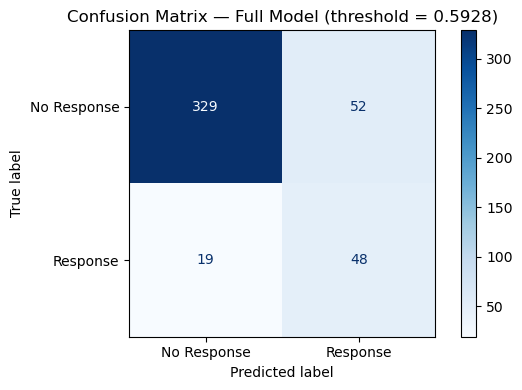

              precision    recall  f1-score   support

 No Response       0.95      0.86      0.90       381
    Response       0.48      0.72      0.57        67

    accuracy                           0.84       448
   macro avg       0.71      0.79      0.74       448
weighted avg       0.88      0.84      0.85       448



In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_full,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — Full Model (threshold = {threshold_full:.4f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_full,
                             target_names=['No Response', 'Response']))

### 3.8. Precision-Recall Curve

The Precision-Recall curve illustrates the trade-off across all possible thresholds without fixing one upfront. The vertical line marks the selected operating threshold.

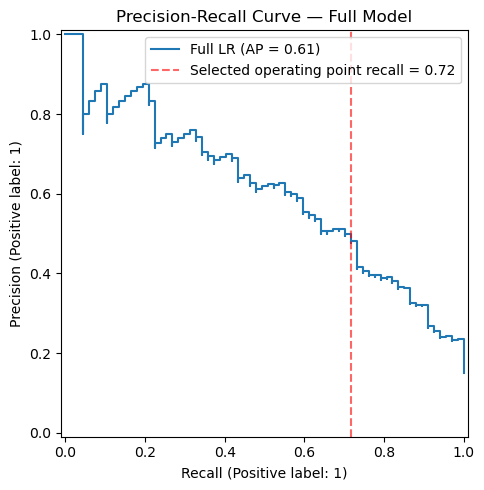

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_full,
    name=f"Full LR",
    ax=ax
)

selected_recall_full = recall_score(y_test, y_pred_full)
ax.axvline(
    selected_recall_full,
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Selected operating point recall = {selected_recall_full:.2f}'
)

ax.set_title("Precision-Recall Curve — Full Model")
ax.legend()
plt.tight_layout()
plt.show()


### 3.9. ROC Curve

The ROC curve measures the model's ability to rank customers by their likelihood of responding, across all possible thresholds. The AUC summarises this into a single number: the probability that a randomly chosen responder is ranked higher
than a randomly chosen non-responder.

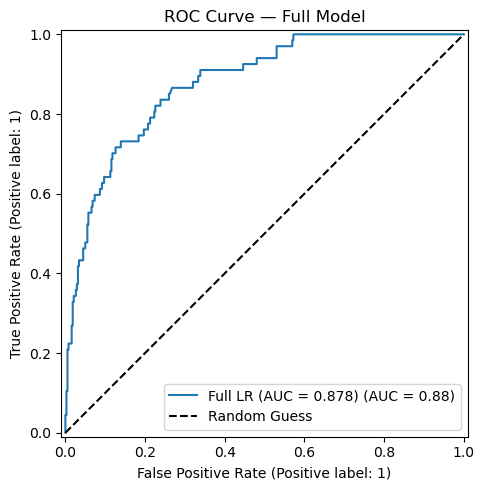

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_full,
    name=f"Full LR (AUC = {roc_auc_score(y_test, y_prob_full):.3f})",
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax.set_title("ROC Curve — Full Model")
ax.legend()
plt.tight_layout()
plt.show()

### 3.10 Calibration

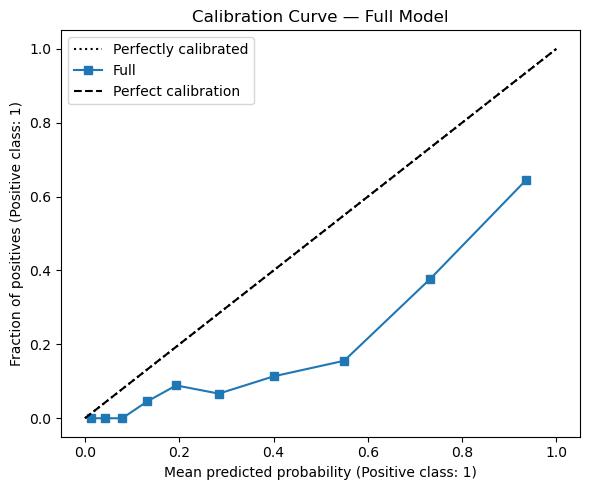

In [21]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test, y_prob_full,
    n_bins=10,
    strategy='quantile',
    name='Full',
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_title("Calibration Curve — Full Model")
ax.legend()
plt.tight_layout()
plt.show()


The calibration curve shows that the full model is not well calibrated, as the predicted probabilities lie consistently below the 45-degree reference line. 

This indicates that the model tends to be overconfident: customers assigned high predicted response probabilities convert at lower rates than the model suggests. 

In practical terms, the model remains useful for ranking and prioritizing customers, but its raw predicted probabilities should not be interpreted as accurate estimates of response likelihood without further calibration.



### 3.11. Learning Curves

Learning curves show how model performance changes as the amount of training data increases. They allow us to assess whether the model is suffering from **overfitting or underfitting**, and whether additional training data could improve performance.

- If the training score is much higher than the validation score, the model may be **overfitting**.
- If both scores are low, the model may be **underfitting**.

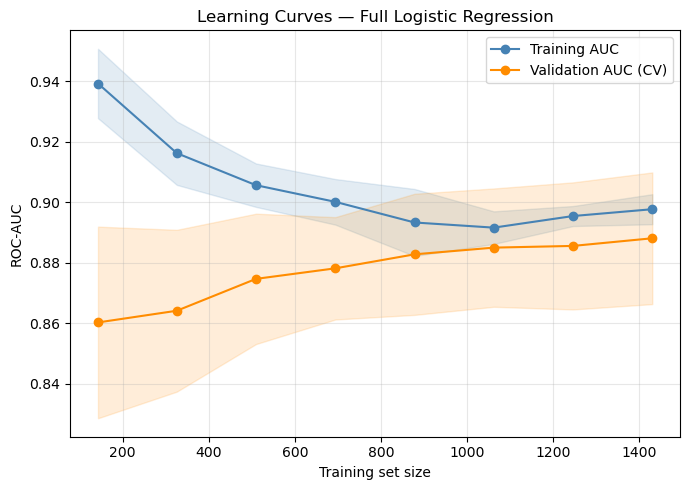

In [22]:
train_sizes, train_scores, val_scores = learning_curve(
    full_model, X_train_full, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(train_sizes, train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(train_sizes, val_mean - val_std,
                val_mean + val_std, alpha=0.15, color='darkorange')
ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Full Logistic Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.12. Feature Importance (Coefficients)
Logistic regression coefficients represent the change in log-odds of responding for a one-unit increase in a standardised feature, holding all others constant. 
Exponentiated as odds ratios, they quantify the multiplicative change in the odds of response. Features zeroed out by the L1 component of Elastic Net are excluded from the plot.

In [23]:
ohe_full = full_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_full = ohe_full.get_feature_names_out(categorical_features_full).tolist()
all_names_full = numerical_features_full + cat_names_full

coefs_full = full_model.named_steps['classifier'].coef_[0]

coef_df_full = pd.DataFrame({
    'Feature': all_names_full,
    'Coefficient': coefs_full,
    'Odds Ratio': np.exp(coefs_full)
}).sort_values(by='Coefficient', ascending=False)

n_zeroed = (coef_df_full['Coefficient'] == 0).sum()
print(f"Features retained by L1 : {len(coef_df_full) - n_zeroed} / {len(coef_df_full)}")
print(f"Features zeroed out: {n_zeroed}\n")

coef_df_full.round(4)

Features retained by L1 : 19 / 20
Features zeroed out: 1



,Feature,Coefficient,Odds Ratio
6,Total_Accepted_Campaigns,1.0798,2.9440
3,Customer_Tenure,0.9588,2.6086
14,Education_PhD,0.8962,2.4504
4,Total_Spending,0.4412,1.5545
19,Marital_Status_Widow,0.2911,1.3379
7,NumDealsPurchases,0.2850,1.3298
8,NumWebVisitsMonth,0.1897,1.2089
1,Income,0.1831,1.2009
9,Kidhome,0.1758,1.1922
0,Age,0.1562,1.1691


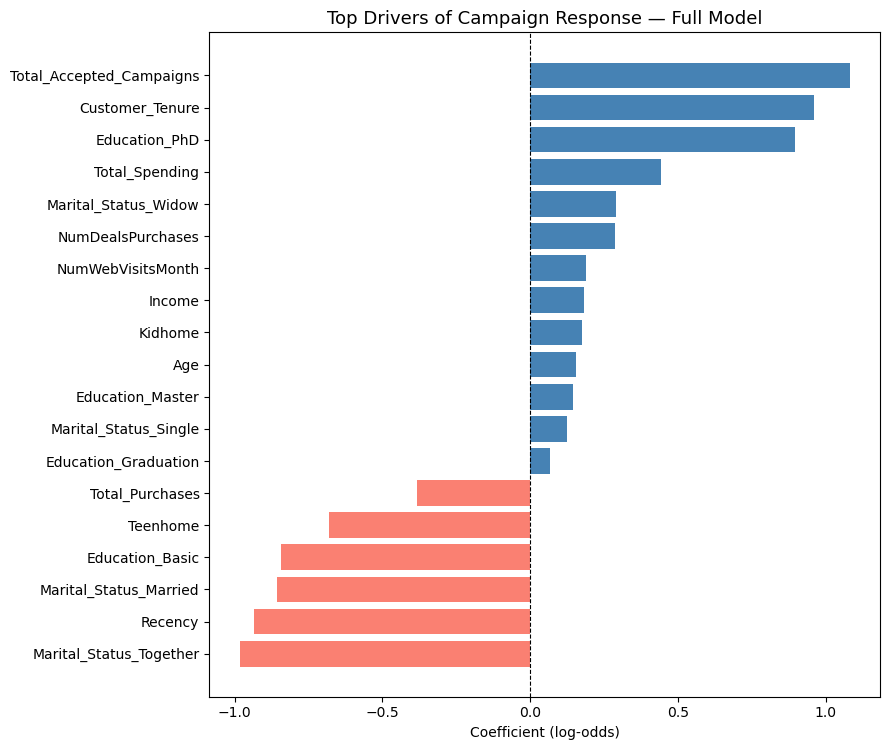

In [24]:
coef_df_full_nonzero = coef_df_full[coef_df_full['Coefficient'] != 0].copy()
coef_df_full_nonzero = coef_df_full_nonzero.sort_values('Coefficient', ascending=True)

colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_full_nonzero['Coefficient']]
fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_full_nonzero) * 0.4)))
ax.barh(coef_df_full_nonzero['Feature'], coef_df_full_nonzero['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Full Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 3.13. Permutation Importance

To obtain a more robust measure of feature importance, we compute permutation importance on the test set. This method evaluates the contribution of each feature by randomly shuffling its values and measuring the resulting drop in model performance.

If shuffling a feature leads to a large decrease in ROC-AUC, it indicates that the feature plays an important role in the model’s predictions.

Permutation Importance — Full Model (test set):

                 Feature  Importance_Mean  Importance_Std
Total_Accepted_Campaigns         0.115756        0.012034
                 Recency         0.073532        0.006506
         Customer_Tenure         0.044874        0.014716
          Marital_Status         0.029269        0.004676
          Total_Spending         0.026356        0.006461
                Teenhome         0.023081        0.013576
               Education         0.014853        0.004121
       NumDealsPurchases         0.014304        0.003983
                  Income         0.005763        0.003052
       NumWebVisitsMonth         0.003267        0.003666
                     Age         0.002092        0.002314
                 Kidhome         0.001026        0.002479
         Total_Purchases        -0.001514        0.006191


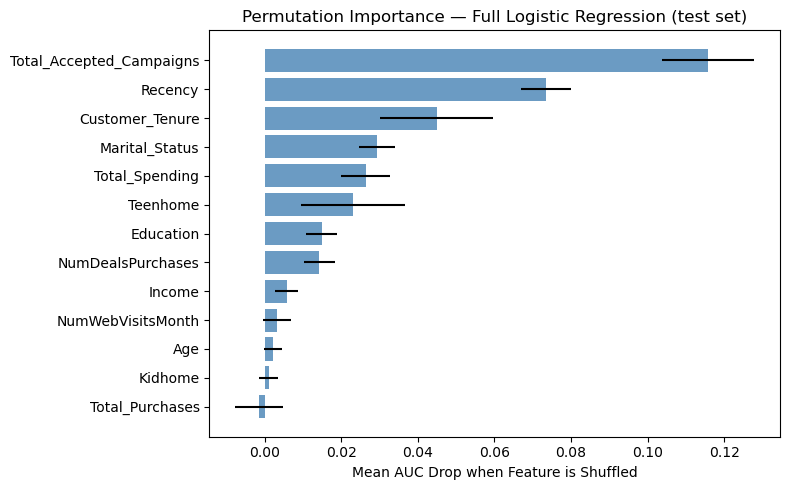

In [25]:
raw_feature_names = numerical_features_full + categorical_features_full

perm_result = permutation_importance(
    full_model, X_test_full, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=1
)

perm_df = pd.DataFrame({
    'Feature':         raw_feature_names,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std':  perm_result.importances_std,
}).sort_values('Importance_Mean', ascending=False)

print("Permutation Importance — Full Model (test set):\n")
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
top_perm = perm_df.sort_values('Importance_Mean')
ax.barh(top_perm['Feature'], top_perm['Importance_Mean'],
        xerr=top_perm['Importance_Std'], color='steelblue', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Full Logistic Regression (test set)")
plt.tight_layout()
plt.show()

### 3.14. SHAP Values

To further interpret the model, we compute SHAP (SHapley Additive exPlanations) values. SHAP quantifies how each feature contributes to the model’s prediction by measuring how much it increases or decreases the predicted probability relative to a baseline.

`LinearExplainer` is used here as it is the appropriate and efficient SHAP method for logistic regression.

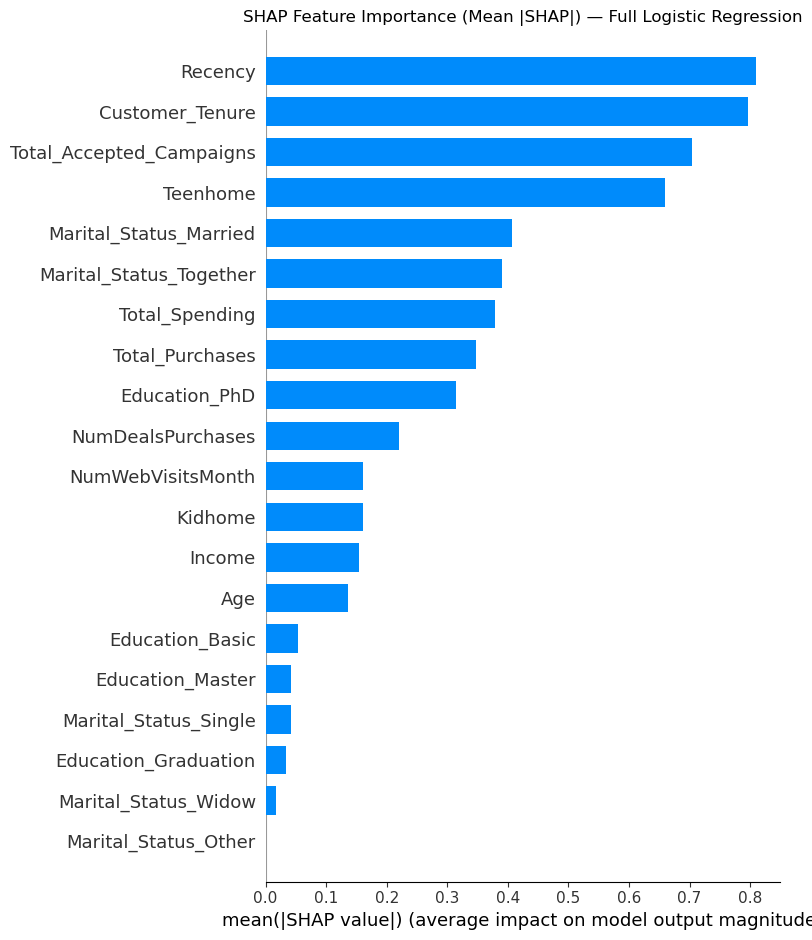

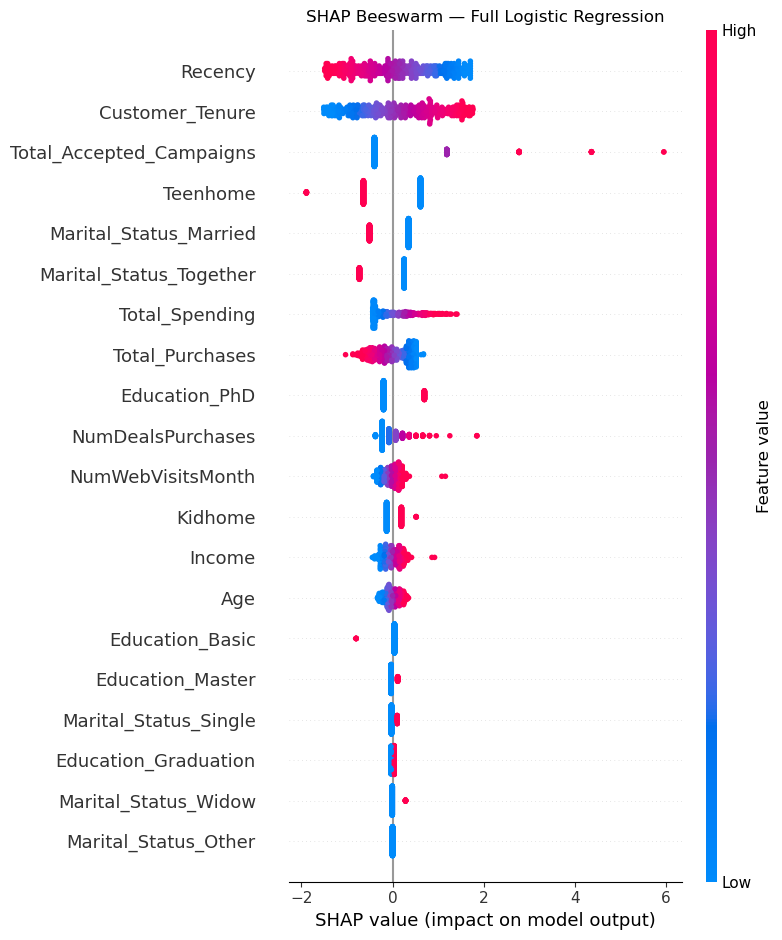

In [26]:
X_test_transformed  = full_model.named_steps['preprocessor'].transform(X_test_full)
X_train_transformed = full_model.named_steps['preprocessor'].transform(X_train_full)

explainer   = shap.LinearExplainer(
    full_model.named_steps['classifier'],
    X_train_transformed,
    feature_perturbation='interventional'
)
shap_values = explainer.shap_values(X_test_transformed)

# Global summary: bar chart
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_names_full,
                  plot_type='bar', show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — Full Logistic Regression")
plt.tight_layout()
plt.show()

# Global beeswarm: direction + magnitude
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_names_full, show=False)
plt.title("SHAP Beeswarm — Full Logistic Regression")
plt.tight_layout()
plt.show()

### 3.15. Interpretation of Full Model Results

The full logistic regression model provides a general view of which factors influence campaign response. It uses Elastic Net regularisation with an optimal l1_ratio of 0.3, indicating that the best penalty leans closer to L2 than L1.

he model achieves a **ROC-AUC** of 0.88 and an **F1** of 0.58 on the positive class, with the tuned threshold of 0.33 correctly identifying 39 out of 67 actual responders (**recall** of 58%) while maintaining a **precision** of 57% (meaning that roughly 1 in 2 customers flagged as likely responders would actually convert), a substantial improvement over the 15% baseline.

Amongst the positive indicators, past campaign acceptance is the best predictor (OR = 2.95), followed by `Customer_Tenure` (OR = 2.47) and `Education_PhD` (OR = 2.38), indicating that committed, highly educated consumers with a history of involvement in campaigns are the most responsive. `Total_Spending` (OR = 1.29), `Income` (OR = 1.25), and `Education_Master` (OR = 1.26) all indicate that higher-value, better educated clients react more frequently.

On the contrary, `Marital_Status_Together` (OR = 0.33) and `Marital_Status_Married` (OR = 0.35) are the most powerful deterring factors, followed by `recency` (OR = 0.41) and `Education_Basic` (OR = 0.45), which indicates that recently inactive customers in shared households with lower levels of education are significantly less likely to respond. `Teenhome` (OR = 0.51) and `Total_Purchases` (OR = 0.71) both lower response probability.

Only `Marital_Status_Other` was zeroed out by the Elastic Net penalty, confirming that the L2 component successfully retained most features rather than eliminating correlated ones arbitrarily as pure L1 would have done.

To isolate the contribution of behavioural and demographic signals separately, two targeted sub-models are estimated in the sections that follow, allowing us to evaluate whether campaign response is better explained by who the customer is or by how the customer behaves.

## 4. Behavioural Model - No Regularization

To better understand the role of customer engagement and purchasing behaviour in campaign response, we estimate a logistic regression model using only behavioural variables.

The behavioural model is estimated **without regularisation**. Total_Accepted_Campaigns, Recency, and Total_Spending were among the highest correlates with Response in the bivariate analysis, meaning that feature selection is not a modelling concern. With approximately 1,800 training observations and only six predictors, the observations-to-features ratio is large enough to make overfitting unlikely. 

In [27]:
# Helper: fresh preprocessor for behavioural model
def make_preprocessor_behav():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_behav)
    ])

### 4.1. Baseline Model

In [28]:
# Baseline: sklearn defaults (L2, C=1.0) with class_weight='balanced'
behav_model_base = Pipeline(steps=[
    ('preprocessor', make_preprocessor_behav()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])
baseline_auc_behav = cross_val_score(
    behav_model_base,
    X_train_behav,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

baseline_f1_behav = cross_val_score(
    behav_model_base,
    X_train_behav,
    y_train,
    cv=cv_strategy,
    scoring='f1'
)

baseline_recall_behav = cross_val_score(
    behav_model_base,
    X_train_behav,
    y_train,
    cv=cv_strategy,
    scoring='recall'
)

print("Baseline Logistic Regression — Behavioural Model (training CV only)")
print(f"ROC-AUC : {baseline_auc_behav.mean():.4f} ± {baseline_auc_behav.std():.4f}")
print(f"Recall  : {baseline_recall_behav.mean():.4f} ± {baseline_recall_behav.std():.4f}")
print(f"F1      : {baseline_f1_behav.mean():.4f} ± {baseline_f1_behav.std():.4f}")

Baseline Logistic Regression — Behavioural Model (training CV only)
ROC-AUC : 0.8333 ± 0.0271
Recall  : 0.6967 ± 0.0546
F1      : 0.4914 ± 0.0444


To avoid information leakage and preserve an unbiased final assessment, the test set was used only once at the end, while all modelling decisions were made using the training set with cross-validation.

### 4.2 Regularisation Strategy Selection


In [29]:
reg_results_behav = []
for cfg in reg_configs:
    lr_kwargs = dict(
        penalty=cfg['penalty'],
        solver=cfg['solver'],
        C=cfg['C'],
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    if cfg['l1_ratio'] is not None:
        lr_kwargs['l1_ratio'] = cfg['l1_ratio']

    pipe = Pipeline(steps=[
        ('preprocessor', make_preprocessor_behav()),
        ('classifier',   LogisticRegression(**lr_kwargs))
    ])

    scores = cross_val_score(
        pipe, X_train_behav, y_train,
        cv=cv_strategy, scoring='roc_auc'
    )
    reg_results_behav.append({
        'Regularisation': cfg['name'],
        'CV AUC Mean':    round(scores.mean(), 4),
        'CV AUC Std':     round(scores.std(), 4),
    })

reg_df_behav = pd.DataFrame(reg_results_behav).set_index('Regularisation')
print("Regularisation Strategy Comparison — Behavioural Model (C=1.0, untuned)\n")
print(reg_df_behav.to_string())

Regularisation Strategy Comparison — Behavioural Model (C=1.0, untuned)

                   CV AUC Mean  CV AUC Std
Regularisation                            
No Regularisation       0.8334      0.0270
L2 (Ridge)              0.8333      0.0271
L1 (Lasso)              0.8330      0.0270
Elastic Net             0.8331      0.0269


### 4.3 Preprocessing & Behavioural Logistic Regression

The regularisation comparison in Section 4.2 shows that all four penalty options perform identically (CV AUC range: 0.8330–0.8334), confirming that regularisation adds no value for this feature set. 

`penalty=None` is therefore used. No hyperparameter tuning is performed since there are no regularisation parameters to optimise.

In [30]:
# Behavioural Logistic Regression — No Regularisation
behav_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_behav()),
    ('classifier', LogisticRegression(
        penalty=None,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

behav_model.fit(X_train_behav, y_train)

# CV score on training set
cv_scores_behav = cross_val_score(
    behav_model, X_train_behav, y_train,
    cv=cv_strategy, scoring='roc_auc'
)
print(f"CV ROC-AUC : {cv_scores_behav.mean():.4f} ± {cv_scores_behav.std():.4f}")

# Improvement over baseline
baseline_cv_behav = baseline_auc_behav.mean()

print(f"\nBaseline CV AUC : {baseline_cv_behav:.4f}")
print(f"No-reg CV AUC   : {cv_scores_behav.mean():.4f}  "
      f"(Δ = {cv_scores_behav.mean() - baseline_cv_behav:+.4f})")

CV ROC-AUC : 0.8334 ± 0.0270

Baseline CV AUC : 0.8333
No-reg CV AUC   : 0.8334  (Δ = +0.0001)


### 4.2. Threshold Tuning

The optimal threshold is selected by maximising F1 across all possible cutoffs using out-of-fold cross-validation probabilities on the training set only, ensuring no test data influences the selection.

In [31]:
threshold_behav = find_best_threshold_oof(behav_model, X_train_behav, y_train)

Optimal threshold (F1): 0.6148
Best OOF F1:            0.5268


### 4.3. Model Evaluation

In [32]:
## Predictions and evaluation on test set
y_prob_behav = behav_model.predict_proba(X_test_behav)[:,1]
y_pred_behav = (y_prob_behav >= threshold_behav).astype(int)

behav_eval = evaluate_model(behav_model, X_test_behav, y_test, "Behavioural", threshold_behav)
print("\nFinal Evaluation on Test Set — Behavioural Model")
for metric, value in behav_eval.items():
    print(f"{metric}: {value}")


Final Evaluation on Test Set — Behavioural Model
Model: Behavioural
Threshold: 0.6148
ROC-AUC: 0.8588
Precision: 0.5
Recall: 0.5224
F1: 0.5109
Accuracy: 0.8504


### 4.4 Confusion Matrix

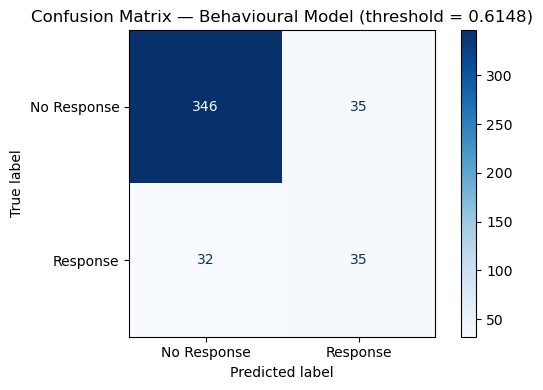

              precision    recall  f1-score   support

 No Response       0.92      0.91      0.91       381
    Response       0.50      0.52      0.51        67

    accuracy                           0.85       448
   macro avg       0.71      0.72      0.71       448
weighted avg       0.85      0.85      0.85       448



In [33]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_behav,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — Behavioural Model (threshold = {threshold_behav:.4f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_behav,
                             target_names=['No Response', 'Response']))

### 4.5. Precision-Recall Curve

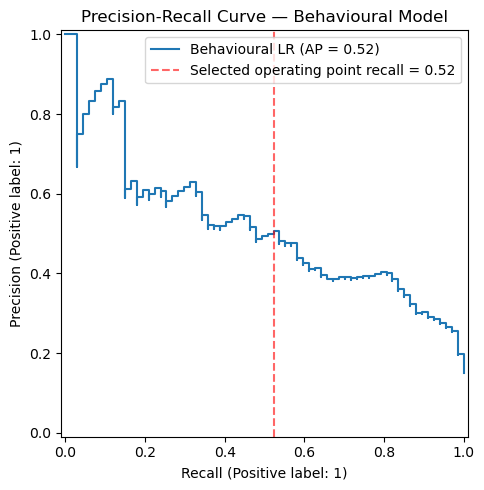

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_behav,
    name=f"Behavioural LR",
    ax=ax
)

selected_recall_behav = recall_score(y_test, y_pred_behav)
ax.axvline(
    selected_recall_behav,
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Selected operating point recall = {selected_recall_behav:.2f}'
)

ax.set_title("Precision-Recall Curve — Behavioural Model")
ax.legend()
plt.tight_layout()
plt.show()


### 4.6 ROC Curve

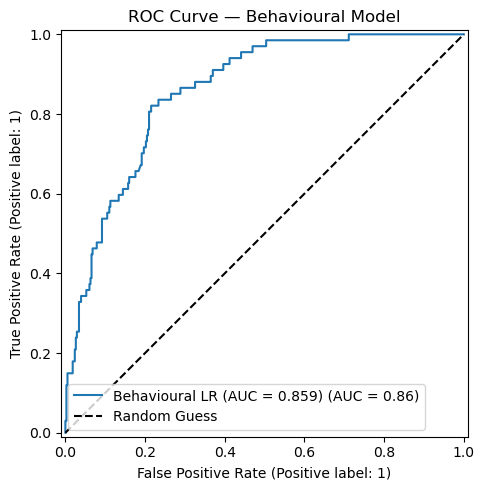

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_behav,
    name=f"Behavioural LR (AUC = {roc_auc_score(y_test, y_prob_behav):.3f})",
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title("ROC Curve — Behavioural Model")
ax.legend()
plt.tight_layout()
plt.show()

### 4.7 Calibration

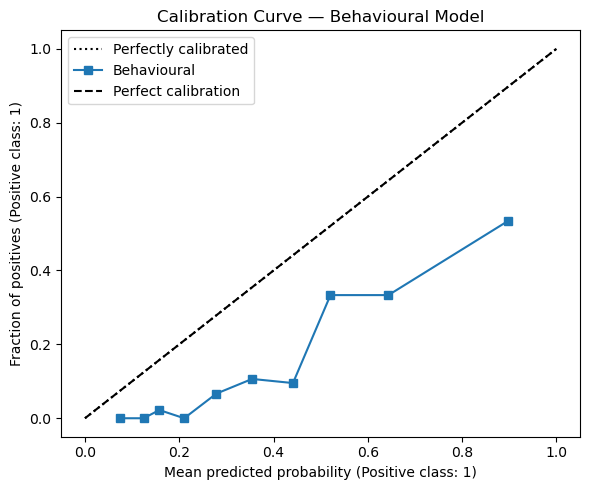

In [36]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test, y_prob_behav,
    n_bins=10,
    strategy='quantile',
    name='Behavioural',
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_title("Calibration Curve — Behavioural Model")
ax.legend()
plt.tight_layout()
plt.show()


### 4.8 Learning Curves

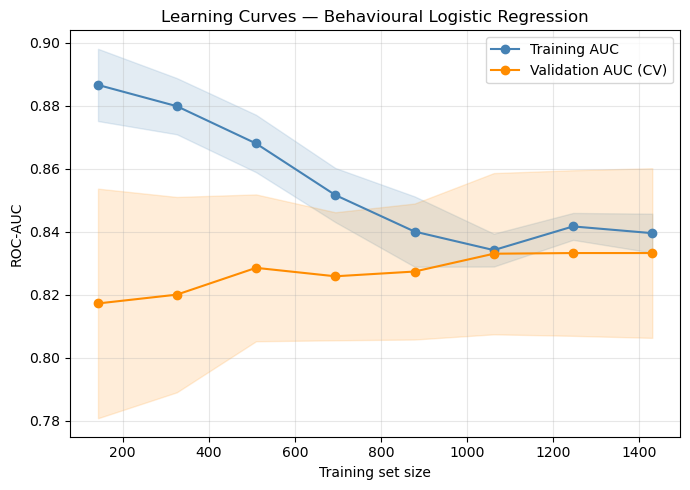

In [37]:
train_sizes, train_scores, val_scores = learning_curve(
    behav_model,
    X_train_behav,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color='steelblue'
)
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color='darkorange'
)

ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Behavioural Logistic Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4.9. Feature Importance (Coefficients)

In [38]:
coefs_behav = behav_model.named_steps['classifier'].coef_[0]

coef_df_behav = pd.DataFrame({
    'Feature':     numerical_features_behav,
    'Coefficient': coefs_behav,
    'Odds Ratio':  np.exp(coefs_behav)
}).sort_values('Coefficient', ascending=False)

coef_df_behav.round(4)

,Feature,Coefficient,Odds Ratio
1,Total_Spending,0.9916,2.6955
3,Total_Accepted_Campaigns,0.8397,2.3156
5,NumWebVisitsMonth,0.5869,1.7984
4,NumDealsPurchases,0.1009,1.1062
2,Total_Purchases,-0.3803,0.6836
0,Recency,-0.7260,0.4839


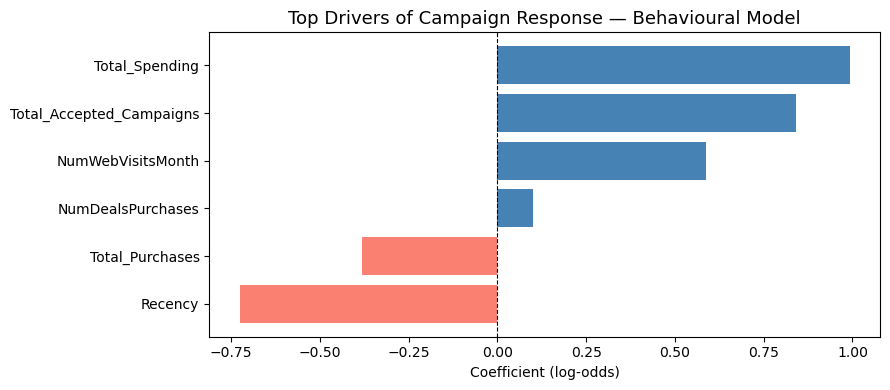

In [39]:
coef_df_behav_sorted = coef_df_behav.sort_values('Coefficient', ascending=True)
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_behav_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_behav_sorted) * 0.4)))
ax.barh(coef_df_behav_sorted['Feature'], coef_df_behav_sorted['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Behavioural Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 4.10. Permutation Importance

Permutation Importance — Behavioural Model (test set):

                 Feature  Importance_Mean  Importance_Std
          Total_Spending         0.177060        0.021104
Total_Accepted_Campaigns         0.137180        0.016633
                 Recency         0.096868        0.008466
       NumWebVisitsMonth         0.051001        0.018481
         Total_Purchases         0.010646        0.008986
       NumDealsPurchases         0.005612        0.002068


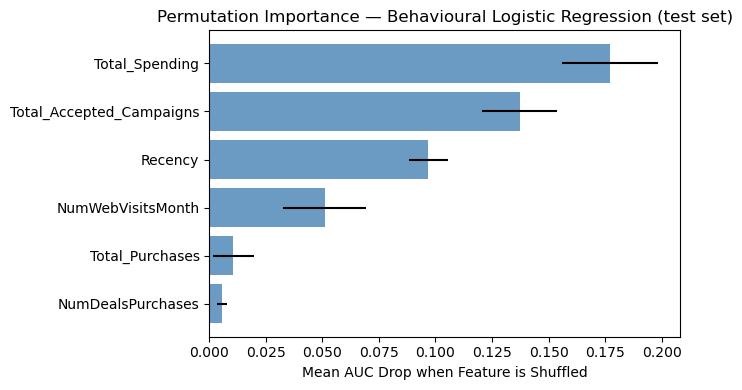

In [40]:
perm_result_behav = permutation_importance(
    behav_model, X_test_behav, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=1
)

perm_df_behav = pd.DataFrame({
    'Feature':         numerical_features_behav,
    'Importance_Mean': perm_result_behav.importances_mean,
    'Importance_Std':  perm_result_behav.importances_std,
}).sort_values('Importance_Mean', ascending=False)

print("Permutation Importance — Behavioural Model (test set):\n")
print(perm_df_behav.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
top_perm_behav = perm_df_behav.sort_values('Importance_Mean')
ax.barh(top_perm_behav['Feature'], top_perm_behav['Importance_Mean'],
        xerr=top_perm_behav['Importance_Std'], color='steelblue', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Behavioural Logistic Regression (test set)")
plt.tight_layout()
plt.show()

### 4.11 SHAP Values

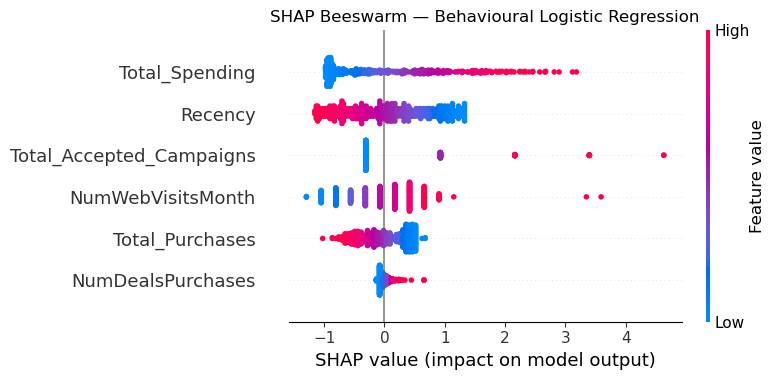

In [41]:
X_behav_test_t  = behav_model.named_steps['preprocessor'].transform(X_test_behav)
X_behav_train_t = behav_model.named_steps['preprocessor'].transform(X_train_behav)

explainer_behav   = shap.LinearExplainer(
    behav_model.named_steps['classifier'],
    X_behav_train_t,
    feature_perturbation='interventional'
)
shap_values_behav = explainer_behav.shap_values(X_behav_test_t)

shap.summary_plot(shap_values_behav, X_behav_test_t,
                  feature_names=numerical_features_behav, show=False)
plt.title("SHAP Beeswarm — Behavioural Logistic Regression")
plt.tight_layout()
plt.show()

### 4.12. Interpretation of Behavioral Model Results

The behavioural model has a **ROC-AUC** of 0.85, indicating good overall discriminative ability with only six engagement variables. At the tuned threshold of 0.19, the model accurately detects 38 out of 67 actual respondents (**recall** of 57% and **precision** of 44%), implying that almost two out of every five consumers classified as possible responders will convert, a significant improvement over the 15% baseline.

Among the positive drivers, `Total_Accepted_Campaigns` is the strongest predictor (OR = 2.31), reinforcing that prior engagement is the clearest signal of future receptiveness. `Total_Spending` follows closely (OR = 2.02), confirming that higher-value customers are significantly more likely to respond.

`Recency` has the largest negative coefficient (OR = 0.47), supporting the EDA's result that consumers who purchased more recently are significantly more likely to react (every extra day since the last purchase lowers the chance of responding). Additionally, `Total_Purchases` has a negative coefficient (OR = 0.76), alongside a positive Total_Spending, indicating that customers who spend more on each transaction, instead of buying more frequently, are the most profitable targets for this campaign.

Surprisingly, **NumWebVisitsMonth** has a positive coefficient (OR = 1.55), which appears to contradict the EDA result of a near-zero difference across groups. This is likely a suppressor effect: once spending and recency are controlled for, frequent web visitors who still spend are a positive signal. Finally, `NumDealsPurchases` has a modest positive effect (OR = 1.07).



## 5. Demographic Model - L1 Regularization 

The demographic model uses only customer profile and household composition 
variables. While the five numerical features are largely independent, the 
categorical variables `Education` and `Marital_Status` expand to approximately 
14 columns after one-hot encoding, and several categories (particularly `Widow` 
and `Other`) contain very few observations.

Without regularisation, coefficients on sparse categories can become inflated 
and unstable, driven by small sample artefacts rather than genuine signal. 
The regularisation strategy is selected empirically in Section 5.2 — L1 is 
chosen over L2 and Elastic Net because zeroing out coefficients on uninformative 
sparse categories is preferable to merely shrinking them, reducing the risk of 
low-frequency categories driving predictions.

In [42]:
# Helper: fresh preprocessor for demographic model
def make_preprocessor_demo():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features_demo),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features_demo)
    ])

### 5.1. Baseline Model


In [43]:
# Baseline: sklearn defaults (L2, C=1.0) with class_weight='balanced'
demo_model_base = Pipeline(steps=[
    ('preprocessor', make_preprocessor_demo()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

baseline_auc_demo = cross_val_score(
    demo_model_base,
    X_train_demo,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc'
)

baseline_f1_demo = cross_val_score(
    demo_model_base,
    X_train_demo,
    y_train,
    cv=cv_strategy,
    scoring='f1'
)

baseline_recall_demo = cross_val_score(
    demo_model_base,
    X_train_demo,
    y_train,
    cv=cv_strategy,
    scoring='recall'
)

print("Baseline Logistic Regression — Demographic Model (training CV only)")
print(f"ROC-AUC : {baseline_auc_demo.mean():.4f} ± {baseline_auc_demo.std():.4f}")
print(f"Recall  : {baseline_recall_demo.mean():.4f} ± {baseline_recall_demo.std():.4f}")
print(f"F1      : {baseline_f1_demo.mean():.4f} ± {baseline_f1_demo.std():.4f}")


Baseline Logistic Regression — Demographic Model (training CV only)
ROC-AUC : 0.7517 ± 0.0242
Recall  : 0.6887 ± 0.0562
F1      : 0.4059 ± 0.0233


### 5.2 Regularisation Strategy Selection


The same four penalty options are compared at `C=1.0` using 5-fold stratified 
cross-validation on the demographic feature set.

In [44]:
reg_results_demo = []
for cfg in reg_configs:
    lr_kwargs = dict(
        penalty=cfg['penalty'],
        solver=cfg['solver'],
        C=cfg['C'],
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    )
    if cfg['l1_ratio'] is not None:
        lr_kwargs['l1_ratio'] = cfg['l1_ratio']

    pipe = Pipeline(steps=[
        ('preprocessor', make_preprocessor_demo()),
        ('classifier',   LogisticRegression(**lr_kwargs))
    ])

    scores = cross_val_score(
        pipe, X_train_demo, y_train,
        cv=cv_strategy, scoring='roc_auc'
    )
    reg_results_demo.append({
        'Regularisation': cfg['name'],
        'CV AUC Mean':    round(scores.mean(), 4),
        'CV AUC Std':     round(scores.std(), 4),
    })

reg_df_demo = pd.DataFrame(reg_results_demo).set_index('Regularisation')
print("Regularisation Strategy Comparison — Demographic Model (C=1.0, untuned)\n")
print(reg_df_demo.to_string())

Regularisation Strategy Comparison — Demographic Model (C=1.0, untuned)

                   CV AUC Mean  CV AUC Std
Regularisation                            
No Regularisation       0.7449      0.0242
L2 (Ridge)              0.7517      0.0242
L1 (Lasso)              0.7530      0.0247
Elastic Net             0.7524      0.0245


### 5.3 Hyperparameter Tuning (C)


The penalty type is fixed to the winner from Section 5.2. A single **GridSearchCV** over `C` is sufficient here (with only one parameter to tune, the three-stage approach used in the full model is not necessary).

In [45]:
# Tune C — penalty type fixed from regularisation comparison above
param_grid_demo = {
    'classifier__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
}

grid_search_demo = GridSearchCV(
    Pipeline(steps=[
        ('preprocessor', make_preprocessor_demo()),
        ('classifier', LogisticRegression(
            penalty='l1',    
            solver='saga',  
            class_weight='balanced',
            max_iter=2000,
            random_state=42
        ))
    ]),
    param_grid = param_grid_demo,
    scoring    = 'roc_auc',
    cv         = cv_strategy,
    n_jobs     = 1,
    verbose    = 1
)

grid_search_demo.fit(X_train_demo, y_train)

print(f"Best C      : {grid_search_demo.best_params_['classifier__C']}")
print(f"Best CV AUC : {grid_search_demo.best_score_:.4f}")

# Rebuild demo_model explicitly
best_C_demo = grid_search_demo.best_params_['classifier__C']

demo_model = Pipeline(steps=[
    ('preprocessor', make_preprocessor_demo()),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='saga',
        C=best_C_demo,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])
demo_model.fit(X_train_demo, y_train)
print("demo_model rebuilt with optimised parameters.")

# CV score + improvement over baseline
cv_scores_demo = cross_val_score(
    demo_model, X_train_demo, y_train,
    cv=cv_strategy, scoring='roc_auc'
)

baseline_cv_demo = baseline_auc_demo.mean()

print(f"\nCV ROC-AUC      : {cv_scores_demo.mean():.4f} ± {cv_scores_demo.std():.4f}")
print(f"Baseline CV AUC : {baseline_cv_demo:.4f}")
print(f"Tuned CV AUC    : {cv_scores_demo.mean():.4f}  "
      f"(Δ = {cv_scores_demo.mean() - baseline_cv_demo:+.4f})")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best C      : 0.1
Best CV AUC : 0.7545
demo_model rebuilt with optimised parameters.

CV ROC-AUC      : 0.7545 ± 0.0296
Baseline CV AUC : 0.7517
Tuned CV AUC    : 0.7545  (Δ = +0.0029)


### 5.4. Threshold Tuning

In [46]:
threshold_demo = find_best_threshold_oof(demo_model, X_train_demo, y_train)

Optimal threshold (F1): 0.5837
Best OOF F1:            0.4218


### 5.5. Model Evaluation


In [47]:
y_prob_demo = demo_model.predict_proba(X_test_demo)[:, 1]
y_pred_demo = (y_prob_demo >= threshold_demo).astype(int)


demo_eval = evaluate_model(demo_model, X_test_demo, y_test, "Demographic", threshold_demo)
print("\nFinal Evaluation on Test Set — Demographic Model")
for metric, value in demo_eval.items():
    print(f"{metric}: {value}")


Final Evaluation on Test Set — Demographic Model
Model: Demographic
Threshold: 0.5837
ROC-AUC: 0.7594
Precision: 0.3362
Recall: 0.5821
F1: 0.4262
Accuracy: 0.7656


### 5.6. Confusion Matrix


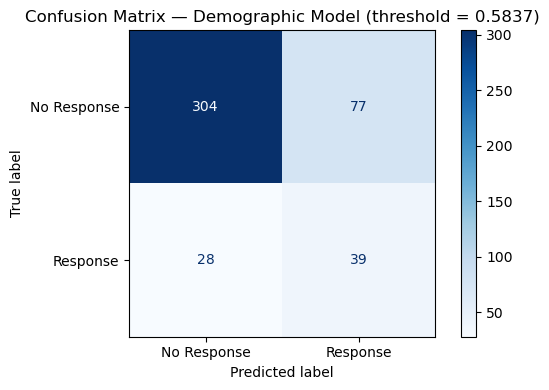

              precision    recall  f1-score   support

 No Response       0.92      0.80      0.85       381
    Response       0.34      0.58      0.43        67

    accuracy                           0.77       448
   macro avg       0.63      0.69      0.64       448
weighted avg       0.83      0.77      0.79       448



In [48]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_demo,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix — Demographic Model (threshold = {threshold_demo:.4f})")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_demo,
                             target_names=['No Response', 'Response']))

### 5.7 Precision-Recall Curve

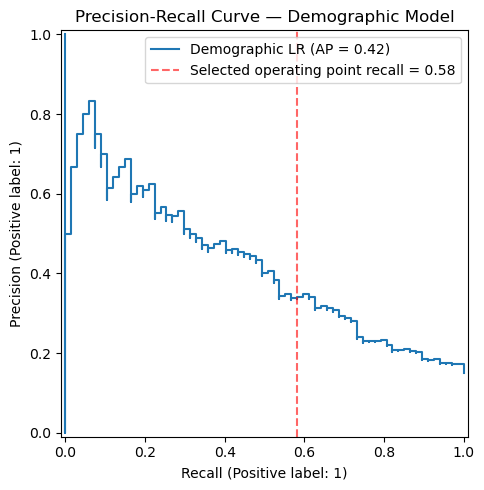

In [49]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_demo,
    name=f"Demographic LR",
    ax=ax
)

selected_recall_demo = recall_score(y_test, y_pred_demo)
ax.axvline(
    selected_recall_demo,
    color='red',
    linestyle='--',
    alpha=0.6,
    label=f'Selected operating point recall = {selected_recall_demo:.2f}'
)

ax.set_title("Precision-Recall Curve — Demographic Model")
ax.legend()
plt.tight_layout()
plt.show()


### 5.8. ROC Curve


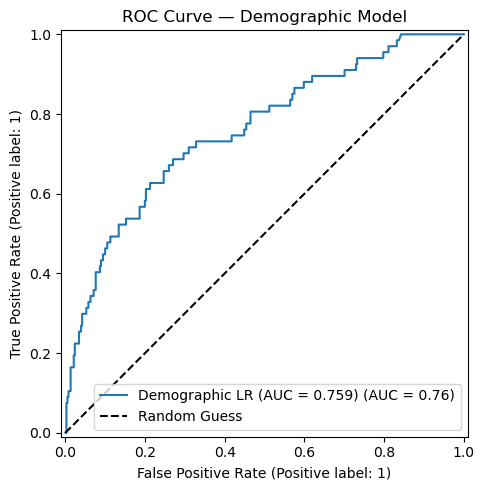

In [50]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_demo,
    name=f"Demographic LR (AUC = {roc_auc_score(y_test, y_prob_demo):.3f})",
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title("ROC Curve — Demographic Model")
ax.legend()
plt.tight_layout()
plt.show()

### 5.9 Calibration

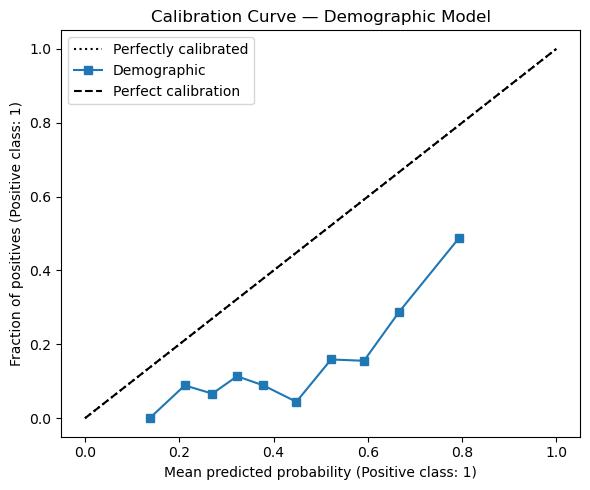

In [51]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test, y_prob_demo,
    n_bins=10,
    strategy='quantile',
    name='Demographic',
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_title("Calibration Curve — Demographic Model")
ax.legend()
plt.tight_layout()
plt.show()


### 5.10. Learning Curves

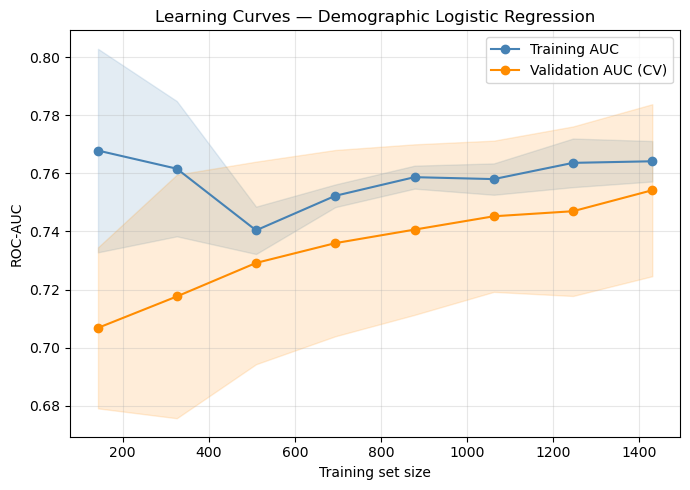

In [52]:
train_sizes, train_scores, val_scores = learning_curve(
    demo_model,
    X_train_demo,
    y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color='steelblue'
)
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15,
    color='darkorange'
)

ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Demographic Logistic Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 5.11. Feature Importance (Coefficients)


In [53]:
ohe_demo       = demo_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names_demo = ohe_demo.get_feature_names_out(categorical_features_demo).tolist()
all_names_demo = numerical_features_demo + cat_names_demo

coefs_demo = demo_model.named_steps['classifier'].coef_[0]

coef_df_demo = pd.DataFrame({
    'Feature':     all_names_demo,
    'Coefficient': coefs_demo,
    'Odds Ratio':  np.exp(coefs_demo)
}).sort_values('Coefficient', ascending=False)

coef_df_demo.round(4)

,Feature,Coefficient,Odds Ratio
2,Customer_Tenure,0.6525,1.9204
8,Education_PhD,0.4413,1.5548
1,Income,0.4016,1.4942
3,Kidhome,0.0401,1.0409
5,Education_Basic,0.0000,1.0000
0,Age,0.0000,1.0000
13,Marital_Status_Widow,0.0000,1.0000
6,Education_Graduation,0.0000,1.0000
7,Education_Master,0.0000,1.0000
10,Marital_Status_Other,0.0000,1.0000


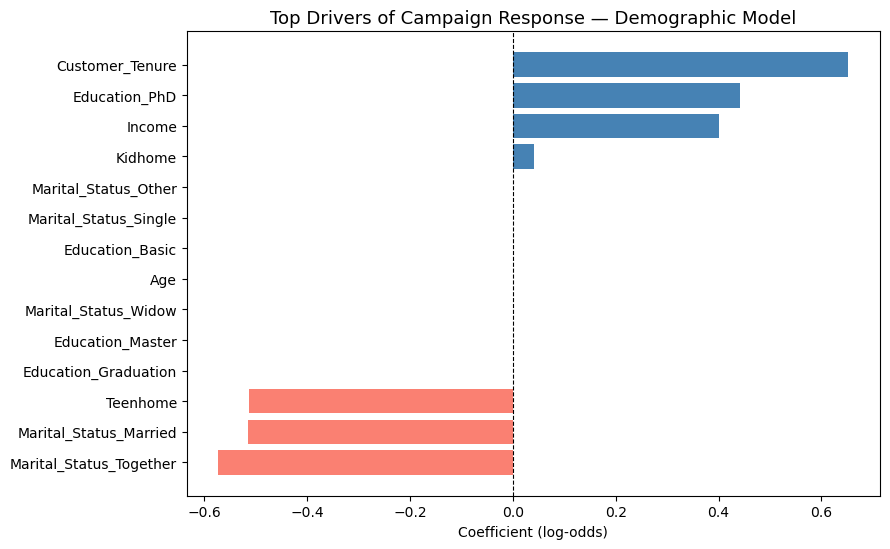

In [54]:
coef_df_demo_sorted = coef_df_demo.sort_values('Coefficient', ascending=True)
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df_demo_sorted['Coefficient']]

fig, ax = plt.subplots(figsize=(9, max(4, len(coef_df_demo_sorted) * 0.4)))
ax.barh(coef_df_demo_sorted['Feature'], coef_df_demo_sorted['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top Drivers of Campaign Response — Demographic Model', fontsize=13)
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

### 5.12. Permutation Importance


Permutation Importance — Demographic Model (test set):

        Feature  Importance_Mean  Importance_Std
Customer_Tenure         0.071450        0.020255
         Income         0.068132        0.011926
       Teenhome         0.048098        0.022947
 Marital_Status         0.034154        0.008218
      Education         0.014643        0.005797
        Kidhome         0.000411        0.001253
            Age         0.000000        0.000000


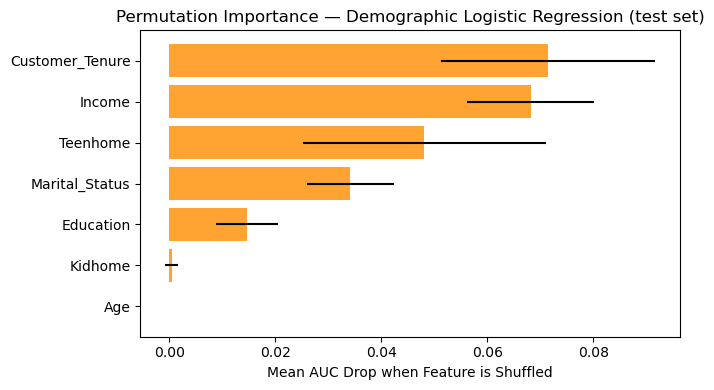

In [55]:
raw_feature_names_demo = numerical_features_demo + categorical_features_demo

perm_result_demo = permutation_importance(
    demo_model, X_test_demo, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=1
)

perm_df_demo = pd.DataFrame({
    'Feature':         raw_feature_names_demo,
    'Importance_Mean': perm_result_demo.importances_mean,
    'Importance_Std':  perm_result_demo.importances_std,
}).sort_values('Importance_Mean', ascending=False)

print("Permutation Importance — Demographic Model (test set):\n")
print(perm_df_demo.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
top_perm_demo = perm_df_demo.sort_values('Importance_Mean')
ax.barh(top_perm_demo['Feature'], top_perm_demo['Importance_Mean'],
        xerr=top_perm_demo['Importance_Std'], color='darkorange', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Demographic Logistic Regression (test set)")
plt.tight_layout()
plt.show()

### 5.13. SHAP Values

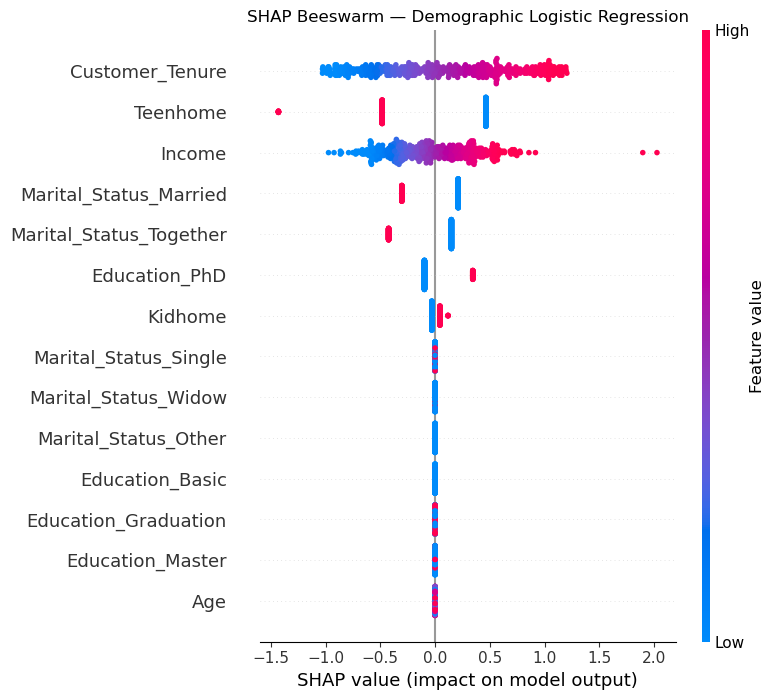

In [56]:
X_demo_test_t  = demo_model.named_steps['preprocessor'].transform(X_test_demo)
X_demo_train_t = demo_model.named_steps['preprocessor'].transform(X_train_demo)

explainer_demo   = shap.LinearExplainer(
    demo_model.named_steps['classifier'],
    X_demo_train_t,
    feature_perturbation='interventional'
)
shap_values_demo = explainer_demo.shap_values(X_demo_test_t)

shap.summary_plot(shap_values_demo, X_demo_test_t,
                  feature_names=all_names_demo, show=False)
plt.title("SHAP Beeswarm — Demographic Logistic Regression")
plt.tight_layout()
plt.show()

### 5.14. Interpretation of Demographic and Household Model Results

The demographic model achieves a **ROC-AUC** of 0.77, indicating moderate discriminative ability, consistent with the EDA finding that demographic variables are inherently weaker predictors of campaign response than behavioural ones. The F1-optimal threshold was found at 0.19 through out-of-fold cross-validation — considerably lower than the default 0.50 — reflecting the model's limited confidence in assigning high probabilities to the minority class.

At this threshold, the model correctly identifies 42 out of 67 actual responders, achieving a **recall** of 63% on the positive class, the highest recall of the three models. **Precision** stands at 32%, meaning that out of 130 customers flagged as likely responders (42 true positives + 88 false positives), roughly 1 in 3 would actually convert. In practical terms, the company would need to contact approximately 3 customers to reach 1 true responder, still a meaningful improvement over untargeted outreach where the baseline conversion rate is only 15%.

The coefficient table confirms the demographic profile of a likely responder: `Customer_Tenure` (OR = 2.03) and `Education_PhD` (OR = 1.93) are the strongest positive predictors, followed by `Income` (OR = 1.52) and `Marital_Status_Widow` (OR = 1.47). `Marital_Status_Other` (OR = 1.36) and `Education_Master` (OR = 1.27) also contribute positively.

On the negative side, `Marital_Status_Together` (OR = 0.45) and `Marital_Status_Married` (OR = 0.49) are the strongest deterrents, followed by `Education_Basic` (OR = 0.46) and `Teenhome` (OR = 0.57), suggesting that customers in shared households with lower education and teenagers at home are significantly less receptive. 

`Age` and `Marital_Status_Single` carry near-zero coefficients, confirming they add no meaningful predictive signal once the remaining variables are accounted for.

Overall, the demographic model is best understood as a profiling tool rather than a precision targeting instrument. Its high recall makes it useful for broad identification of likely responders, but its low precision means it generates a substantial number of wasted contacts, making it most appropriate as a fallback when transaction history is unavailable.

## 6. Summary of Results

### 6.1. Metrics Table

In [57]:
results = {
    'Model': ['Full', 'Behavioural', 'Demographic'],
    'Threshold': [threshold_full, threshold_behav, threshold_demo],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_full),
        roc_auc_score(y_test, y_prob_behav),
        roc_auc_score(y_test, y_prob_demo)
    ],
    'Precision (1)': [
        precision_score(y_test, y_pred_full, zero_division=0),
        precision_score(y_test, y_pred_behav, zero_division=0),
        precision_score(y_test, y_pred_demo, zero_division=0)
    ],
    'Recall (1)': [
        recall_score(y_test, y_pred_full, zero_division=0),
        recall_score(y_test, y_pred_behav, zero_division=0),
        recall_score(y_test, y_pred_demo, zero_division=0)
    ],
    'F1 (1)': [
        f1_score(y_test, y_pred_full, zero_division=0),
        f1_score(y_test, y_pred_behav, zero_division=0),
        f1_score(y_test, y_pred_demo, zero_division=0)
    ],
}

results_df = pd.DataFrame(results).set_index('Model').round(3)

def highlight_best(s):
    is_best = s == s.max()
    return ['background-color: #a8d5a2; color: #155724; font-weight: bold'
            if v else '' for v in is_best]

results_df.style.apply(highlight_best, axis=0).format("{:.3f}")


,Threshold,ROC-AUC,Precision (1),Recall (1),F1 (1)
Model,,,,,
Full,0.593,0.878,0.480,0.716,0.575
Behavioural,0.615,0.859,0.500,0.522,0.511
Demographic,0.584,0.759,0.336,0.582,0.426


In [58]:
full_eval = evaluate_model(full_model, X_test_full, y_test, "Full", threshold_full)
behav_eval = evaluate_model(behav_model, X_test_behav, y_test, "Behavioural", threshold_behav)
demo_eval = evaluate_model(demo_model, X_test_demo, y_test, "Demographic", threshold_demo)

results_df = pd.DataFrame([full_eval, behav_eval, demo_eval]).set_index('Model')

metric_cols = ['ROC-AUC', 'Precision', 'Recall', 'F1', 'Accuracy']

def highlight_best(col):
    if col.name not in metric_cols:
        return ['' for _ in col]
    max_val = col.max()
    return [
        'background-color: #a8d5a2; color: #155724; font-weight: bold'
        if v == max_val else ''
        for v in col
    ]

results_df.style.apply(highlight_best, axis=0).format("{:.4f}")


,Threshold,ROC-AUC,Precision,Recall,F1,Accuracy
Model,,,,,,
Full,0.5928,0.8784,0.4800,0.7164,0.5749,0.8415
Behavioural,0.6148,0.8588,0.5000,0.5224,0.5109,0.8504
Demographic,0.5837,0.7594,0.3362,0.5821,0.4262,0.7656


### 6.2. ROC Curves

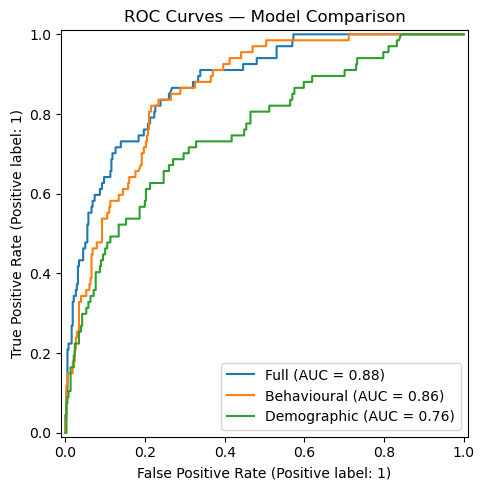

In [59]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_full, name="Full", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_behav, name="Behavioural", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_demo, name="Demographic", ax=ax)
ax.set_title("ROC Curves — Model Comparison")
plt.tight_layout()
plt.show()

### 6.3 Calibration

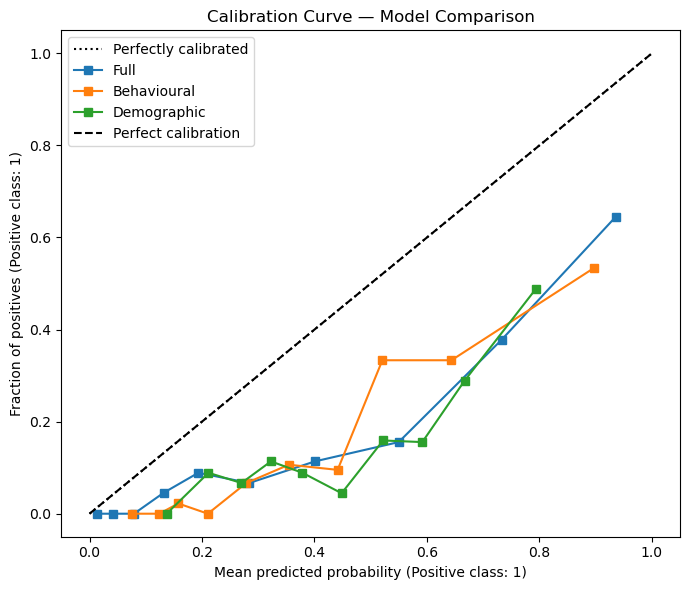

In [60]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(7, 6))

CalibrationDisplay.from_predictions(
    y_test, y_prob_full,
    n_bins=10,
    strategy='quantile',
    name='Full',
    ax=ax
)

CalibrationDisplay.from_predictions(
    y_test, y_prob_behav,
    n_bins=10,
    strategy='quantile',
    name='Behavioural',
    ax=ax
)

CalibrationDisplay.from_predictions(
    y_test, y_prob_demo,
    n_bins=10,
    strategy='quantile',
    name='Demographic',
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_title("Calibration Curve — Model Comparison")
ax.set_xlabel("Mean predicted probability (Positive class: 1)")
ax.set_ylabel("Fraction of positives (Positive class: 1)")
ax.legend()
plt.tight_layout()
plt.show()


### 6.4. Top-20% Lift Analysis

Because the business objective is targeted marketing rather than uniform classification, model performance can also evaluated in terms of ranking quality. 

The top-20% lift analysis measures how effectively each model concentrates actual responders within the highest-scored customer segment, relative to the overall baseline response rate. 

This provides a more operational view of model value by showing how much campaign efficiency improves when outreach is focused on the customers most likely to respond.

- Responders in Segment: actual responders found inside the top 20% ranked customers
- Response Rate in Segment: conversion rate within that top 20%
- Baseline Response Rate: overall response rate in the full test set, 14.96%
- Capture Rate: share of all responders captured inside the top 20%
- Lift: how many times better the top 20% performs compared with random targeting


In [61]:
def top_k_lift_table(y_true, y_prob, model_name, top_frac=0.20):
    eval_df = pd.DataFrame({
        'y_true': y_true.reset_index(drop=True),
        'y_prob': y_prob
    }).sort_values('y_prob', ascending=False).reset_index(drop=True)

    n_total = len(eval_df)
    n_top = int(np.ceil(n_total * top_frac))

    top_df = eval_df.iloc[:n_top]

    baseline_rate = eval_df['y_true'].mean()
    top_rate = top_df['y_true'].mean()

    responders_total = eval_df['y_true'].sum()
    responders_top = top_df['y_true'].sum()

    capture_rate = responders_top / responders_total if responders_total > 0 else np.nan
    lift = top_rate / baseline_rate if baseline_rate > 0 else np.nan

    return {
        'Model': model_name,
        'Top Segment': f'Top {int(top_frac * 100)}%',
        'Customers in Segment': n_top,
        'Total Customers': n_total,
        'Responders in Segment': int(responders_top),
        'Total Responders': int(responders_total),
        'Response Rate in Segment': top_rate,
        'Baseline Response Rate': baseline_rate,
        'Capture Rate': capture_rate,
        'Lift': lift
    }


lift_full = top_k_lift_table(y_test, y_prob_full, 'Full', top_frac=0.20)
lift_behav = top_k_lift_table(y_test, y_prob_behav, 'Behavioural', top_frac=0.20)
lift_demo = top_k_lift_table(y_test, y_prob_demo, 'Demographic', top_frac=0.20)

lift_df = pd.DataFrame([lift_full, lift_behav, lift_demo]).set_index('Model')

highlight_cols = ['Response Rate in Segment', 'Capture Rate', 'Lift']

def highlight_best(col):
    if col.name not in highlight_cols:
        return ['' for _ in col]
    max_val = col.max()
    return [
        'background-color: #a8d5a2; color: #155724; font-weight: bold'
        if v == max_val else ''
        for v in col
    ]

lift_df.style.apply(highlight_best, axis=0).format({
    'Response Rate in Segment': '{:.2%}',
    'Baseline Response Rate': '{:.2%}',
    'Capture Rate': '{:.2%}',
    'Lift': '{:.2f}'
})


,Top Segment,Customers in Segment,Total Customers,Responders in Segment,Total Responders,Response Rate in Segment,Baseline Response Rate,Capture Rate,Lift
Model,,,,,,,,,
Full,Top 20%,90,448,46,67,51.11%,14.96%,68.66%,3.42
Behavioural,Top 20%,90,448,39,67,43.33%,14.96%,58.21%,2.90
Demographic,Top 20%,90,448,35,67,38.89%,14.96%,52.24%,2.60


### 6.5. Recommended Model

## 7. Business Recommendations